In [3]:
# Import core libraries for data manipulation and visualization
from matplotlib.pyplot import subplots  # For creating figure and axis objects for plotting
import numpy as np  # Numerical computing library for array operations
import pandas as pd  # Data manipulation library for DataFrames
from ISLP.models import ModelSpec as MS  # Model specification tool for creating design matrices

# Import survival analysis tools from the lifelines package
from lifelines import (
    KaplanMeierFitter,  # Fits Kaplan-Meier survival curves (non-parametric estimator)
    CoxPHFitter  # Fits Cox Proportional Hazards models (semi-parametric regression)
)
from lifelines.statistics import (
    logrank_test,  # Tests equality of survival curves between 2 groups
    multivariate_logrank_test  # Tests equality of survival curves among 3+ groups
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Set random seed for reproducibility (following ISLP lab convention)
rng = np.random.default_rng(2025)

# Simulate 500 employees hired over a 5-year period
n_employees = 500

# Department assignment (5 departments with realistic proportions)
# Engineering is largest, HR smallest (typical for tech companies)
departments = rng.choice(
    ['Engineering', 'Sales', 'Marketing', 'HR', 'Operations'], 
    size=n_employees, 
    p=[0.40, 0.25, 0.18, 0.08, 0.09]
)

# Years of prior work experience at hire (0-20 years)
# Use exponential distribution to create right-skewed realistic experience levels
experience = rng.exponential(scale=4.5, size=n_employees)
experience = np.clip(experience, 0, 20)

# Performance rating (1.0-5.0 scale, where higher is better)
# Centered at 3.5 with standard deviation of 0.7 to create realistic distribution
performance = rng.normal(loc=3.5, scale=0.7, size=n_employees)
performance = np.clip(performance, 1.0, 5.0)

# Starting salary in thousands (correlated with experience and department)
# Different departments have different base salary structures
dept_salary_base = {
    'Engineering': 95,  # Highest base (competitive tech market)
    'Sales': 72,        # Lower base but typically has commission
    'Marketing': 78,    # Moderate base
    'HR': 68,           # Lower base
    'Operations': 85    # Good base (technical operations)
}
base_salary = np.array([dept_salary_base[d] for d in departments])
# Add experience premium (~$2.5k per year) plus random variation
salary = base_salary + 2.5 * experience + rng.normal(0, 8, n_employees)
salary = np.clip(salary, 45, 160)

# Remote work assignment (binary: 1 = remote, 0 = on-site)
# Engineering has highest remote proportion, Operations lowest
remote_prob = np.where(
    departments == 'Engineering', 0.60,  # Engineering: 60% remote
    np.where(departments == 'Operations', 0.15,  # Operations: 15% remote
             np.where(departments == 'Sales', 0.40,  # Sales: 40% remote
                     np.where(departments == 'Marketing', 0.45, 0.35)))  # Marketing: 45%, HR: 35%
)
remote_work = rng.binomial(1, remote_prob)

print("Covariates generated successfully!")
print(f"Sample size: {n_employees} employees")
print(f"Remote work proportion: {remote_work.mean():.1%}")

Covariates generated successfully!
Sample size: 500 employees
Remote work proportion: 45.2%


In [5]:
# Simulate employment duration (time until departure) using Cox model structure
# Different departments have different baseline retention patterns
dept_hazard_effects = {
    'Engineering': -0.40,   # Best retention (negative = lower hazard)
    'Sales': 0.45,          # Worst retention (positive = higher hazard)
    'Marketing': 0.18,      # Moderate-poor retention
    'HR': 0.08,             # Moderate retention
    'Operations': -0.25     # Good retention
}
dept_effect = np.array([dept_hazard_effects[d] for d in departments])

# Calculate hazard rate (risk of leaving) based on multiple factors
# Cox model structure: λ(t) = λ₀(t) × exp(β₁X₁ + β₂X₂ + ...)
# Protective factors (negative coefficients): experience, performance, salary, remote work
log_hazard = (
    dept_effect +                          # Department effect
    -0.10 * experience +                   # Each year experience reduces hazard by 9.5% (exp(-0.10)≈0.905)
    -0.40 * (performance - 3.5) +          # Higher performance is strongly protective
    -0.018 * (salary - 85) +               # Higher salary reduces departure risk
    -0.35 * remote_work +                  # Remote work reduces hazard by 30% (exp(-0.35)≈0.70)
    -1.5                                   # Baseline log-hazard
)
lambda_hazard = np.exp(log_hazard)  # Convert to hazard rate

# Generate time to departure from exponential distribution (months)
# Exponential distribution is memoryless and commonly used in survival simulation
time_to_departure = rng.exponential(scale=1/lambda_hazard, size=n_employees)

# Add administrative censoring (employees still at company at study end)
# Study duration varies by employee (12-60 months observation window)
# This creates realistic Type I censoring
study_duration = rng.uniform(low=12, high=60, size=n_employees)

# Observed time is minimum of departure time and censoring time
observed_time = np.minimum(time_to_departure, study_duration)
# Event indicator: 1 = departed (event observed), 0 = still employed (censored)
event_indicator = (time_to_departure <= study_duration).astype(int)

print(f"Survival times generated!")
print(f"Events (departures): {event_indicator.sum()}")
print(f"Censored (still employed): {(1 - event_indicator).sum()}")
print(f"Censoring rate: {(1 - event_indicator).mean():.1%}")

Survival times generated!
Events (departures): 433
Censored (still employed): 67
Censoring rate: 13.4%


In [6]:
# Create final DataFrame with all variables
retention_data = pd.DataFrame({
    'time': observed_time,                    # Employment duration in months
    'event': event_indicator,                 # 1 = left company, 0 = still employed
    'department': pd.Categorical(departments), # Department (categorical)
    'experience': experience,                 # Years of prior experience (continuous)
    'performance': performance,               # Performance rating 1-5 (continuous)
    'salary': salary,                         # Starting salary in thousands (continuous)
    'remote_work': remote_work                # 1 = remote, 0 = on-site (binary)
})

print("=" * 70)
print("EMPLOYEE RETENTION DATASET CREATED")
print("=" * 70)
print(f"Dataset dimensions: {retention_data.shape[0]} employees × {retention_data.shape[1]} variables")
print(f"\nFirst 10 observations:")
print(retention_data.head(10))

EMPLOYEE RETENTION DATASET CREATED
Dataset dimensions: 500 employees × 7 variables

First 10 observations:
        time  event   department  experience  performance      salary  \
0   4.137837      1   Operations    0.841920     2.655509   92.316205   
1   3.282764      1  Engineering    0.946957     3.380019   92.603354   
2  18.432079      1    Marketing    9.409169     2.735693   98.144888   
3   4.663205      1           HR    5.583752     2.030922   76.167897   
4   2.323511      1   Operations    0.686558     3.539874   79.926189   
5  14.018088      1  Engineering    2.070775     3.140689  104.693788   
6  39.645606      0  Engineering   15.157682     4.367160  138.590670   
7   4.476022      1   Operations    3.327090     3.320088   81.560671   
8   4.057824      1    Marketing    2.883564     3.737368   96.047723   
9  16.240357      0  Engineering   15.727998     3.492641  123.907938   

   remote_work  
0            0  
1            1  
2            1  
3            1  
4   

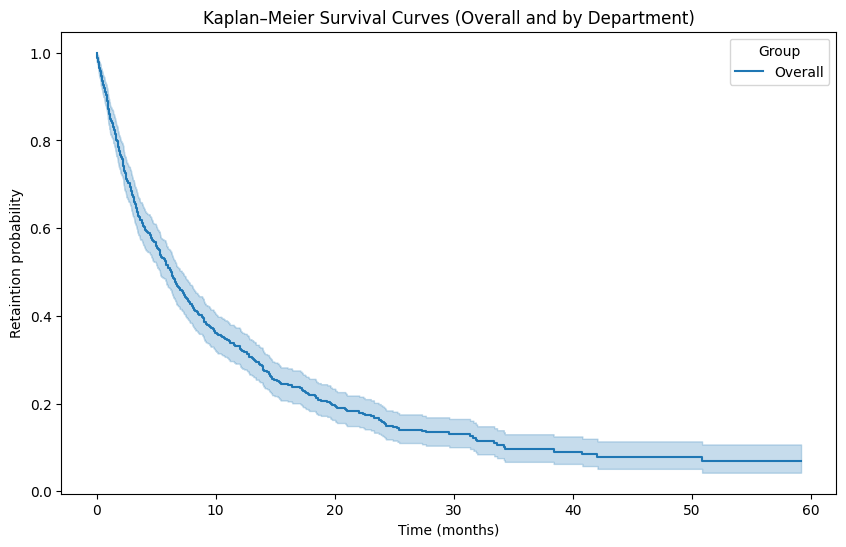

In [8]:
# Fit and plot Kaplan-Meier survival curves (overall and by department)
fig, ax = subplots(figsize=(10, 6))

kmf = KaplanMeierFitter()
# Overall curve
kmf.fit(durations=retention_data['time'], event_observed=retention_data['event'], label='Overall')
kmf.plot_survival_function(ax=ax, ci_show=True)

# Curves by department


ax.set_title('Kaplan–Meier Survival Curves (Overall and by Department)')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Retaintion probability')
ax.legend(title='Group')

In [19]:
median_retention_times = kmf.median_survival_time_
first_quartile = kmf.percentile(.25)
third_quartile = kmf.percentile(.75)
# KaplanMeierFitter is not callable — use predict (or survival_function_at_times) to get probabilities
retention_at_12 = kmf.predict([12])
retention_at_24 = kmf.predict([24])

print("\nOverall median retention time (months):", median_retention_times)
print("Overall 1st quartile (months):", first_quartile)
print("Overall 3rd quartile (months):", third_quartile)
print("Estimated retention probability at 12 :", retention_at_12)
print("Estimated retention probability at 24 :", retention_at_24)


Overall median retention time (months): 6.289403315426682
Overall 1st quartile (months): 15.339461214121911
Overall 3rd quartile (months): 2.2568860333042933
Estimated retention probability at 12 : 0.33200000000000024
Estimated retention probability at 24 : 0.16060105352465648


c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\lifelines\fitters\__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(
c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\lifelines\fitters\__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(


This is abosultely abysmal for HR. Only 33% of workers stay for one year and around half of those remaining leave after additional year. I would say that it probably has to do with being underpayed while over worked at a hihg pressure job. If pay is kept competetive with the market and scales as workers stay, then they should get higher retention, additionall perhaps each person's pay is good enough but the job itself is still too demanding, in which case hiring additional workers would be in order. 


Text(0.5, 1.0, 'Kaplan–Meier Survival Curves by Department')

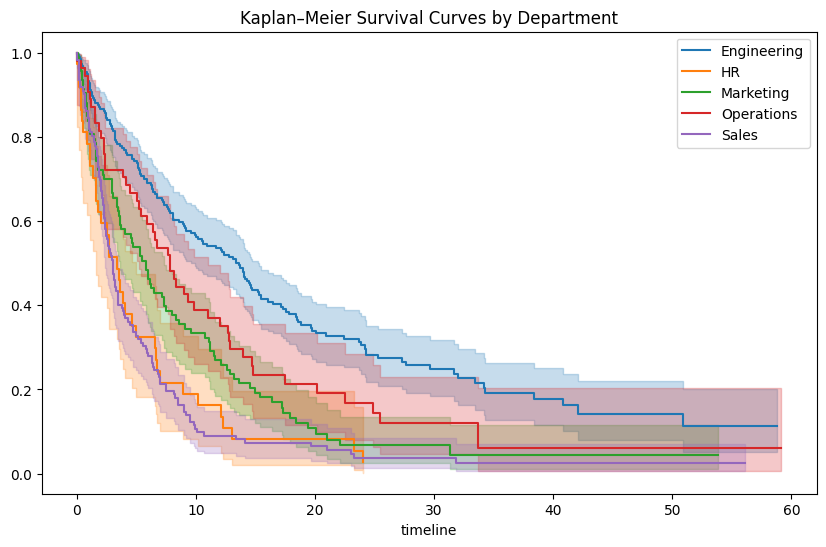

In [ ]:
#### PART 2 

fig, ax = subplots(figsize=(10, 6))

for dept in retention_data['department'].cat.categories:
	mask = retention_data['department'] == dept
	kmf.fit(durations=retention_data.loc[mask, 'time'],
			event_observed=retention_data.loc[mask, 'event'],
			label=str(dept))
	kmf.plot_survival_function(ax=ax, ci_show=True)
	
ax.set_title('Kaplan–Meier Survival Curves by Department')


In [ ]:
median_retention_times_by_dept = {}
for dept in retention_data['department'].cat.categories:
    mask = retention_data['department'] == dept
    kmf.fit(durations=retention_data.loc[mask, 'time'],
            event_observed=retention_data.loc[mask, 'event'],
            label=str(dept))
    median_retention_times_by_dept[dept] = kmf.median_survival_time_
print("\nMedian retention times by department (months):")


median_retention_times_df = pd.DataFrame.from_dict(median_retention_times_by_dept, orient='index', columns=['Median Retention Time (months)'])
print(median_retention_times_df)

###engineering and sales diverge significantly almost immediately, showing that engineering has higher retention from the get-go and sales has lower retention from the start.


Median retention times by department (months):
             Median Retention Time (months)
Engineering                       13.374983
HR                                 3.354284
Marketing                          5.779757
Operations                         7.795713
Sales                              2.986867


Most departents lose over half of their employees within 12 months,with sales, HR, and marketing losing around 75% to 90% within the year. This alsmost certiabnly has to do with marketing and sales having high benchmarks which extrememly low retention for those positions acorss industries. The HR deoartment as a whole could possible be culled, or perhaps a high turn over of the HR means that a retention plan is not able to be formalized and implemeneted. Engineering has arounf 50% at 12 months and this probably due to the fact engineers are incentized the most to stay as some projects may take a significant amount of time. 

A practical solution would to have less stressful enviorments where perfomrance isn't the only becnhmark or perhaps that those with low performance can be trained additionally or mentored more, so as to become more productive in the future. 

In [ ]:
# Perform a multivariate log-rank test comparing retention across the five departments
result = multivariate_logrank_test(
	event_durations=retention_data['time'],
	groups=retention_data['department'],
	event_observed=retention_data['event']
)

# Print test statistic and p-value, plus a summary
print("Log-rank test (all departments):")
print(f"Chi-square statistic: {result.test_statistic:.4f}")
print(f"p-value: {result.p_value:.4e}")
result.print_summary()


Log-rank test (all departments):
Chi-square statistic: 90.1095
p-value: 1.2481e-18


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 4
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          90.11 <0.005     59.48

In [37]:
# Compute difference in median retention (months) between highest and lowest retention departments
# and express the difference as a percentage relative to the lowest-median department.

medians = median_retention_times_df['Median Retention Time (months)']
max_dept = medians.idxmax()
min_dept = medians.idxmin()
max_val = medians.max()
min_val = medians.min()

abs_diff_months = max_val - min_val
pct_diff_vs_low = (abs_diff_months / min_val * 100) if min_val != 0 else np.nan

print(f"Highest retention dept: {max_dept} — median = {max_val:.2f} months")
print(f"Lowest retention dept:  {min_dept} — median = {min_val:.2f} months")
print(f"Absolute difference:    {abs_diff_months:.2f} months")
print(f"Relative to lowest:     {pct_diff_vs_low:.1f}%")

Highest retention dept: Engineering — median = 13.37 months
Lowest retention dept:  Sales — median = 2.99 months
Absolute difference:    10.39 months
Relative to lowest:     347.8%


Based on the log rank test p-value is well below .05 indicating that there is significant differnece in retention by department.

Bonus: I think that the stastiscal differnece matches what people would look at for the business analystics, because you can see by the data that there is a major differnce between the dpearmtnet retention just by the median retention rate.

In [45]:
# Fit a Cox proportional hazards model predicting time until departure using all predictors.
# Encode 'department' as dummy variables (drop_first=True to use a reference level)
dept_dummies = pd.get_dummies(retention_data['department'], prefix='dept', drop_first=True)

# Assemble dataframe for Cox model (use pd.concat to combine DataFrames)
cox_df = pd.concat([
	retention_data[['time', 'event', 'experience', 'performance', 'salary', 'remote_work']],
	dept_dummies
], axis=1)

# Fit Cox Proportional Hazards model
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='time', event_col='event', show_progress=False)

# Display model summary
c_index = cph.concordance_index_
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 500 total observations, 67 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 500
number of events observed = 433
   partial log-likelihood = -2242.39
         time fit was run = 2025-11-21 17:15:01 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
experience      -0.09      0.91      0.02           -0.13           -0.05                0.88                0.95
performance     -0.21      0.81      0.08           -0.36           -0.06                0.70                0.94
salary          -0.02      0.98      0.01           -0.03           -0.01                0.97                0.99
remote_work     -0.52      0.60      0.10           -0.72           -0.32                0.49                0.73
dept_HR          0.76      2.14      0.24            0.29            1.23                1.33                3.43
dept_Marketing   0.54      1.72      0.17            0.21            0.87                1.24                2.38
dept_Operations  0.25      1.28      0.18           -0.11            0.60                0.90                1.83
dept_Sales       0.94      2.57      0.19            0.57            1.31                1.77                3.71

                 cmp to     z      p  -log2(p)
covariate                                     
experience         0.00 -4.46 <0.005     16.87
performance        0.00 -2.80   0.01      7.60
salary             0.00 -3.46 <0.005     10.85
remote_work        0.00 -5.06 <0.005     21.19
dept_HR            0.00  3.14 <0.005      9.20
dept_Marketing     0.00  3.25 <0.005      9.75
dept_Operations    0.00  1.36   0.17      2.53
dept_Sales         0.00  5.00 <0.005     20.74
---
Concordance = 0.71
Partial AIC = 4500.77
log-likelihood ratio test = 243.36 on 8 df
-log2(p) of ll-ratio test = 157.32

In [48]:
# Report exponentiated coefficients (hazard ratios) for selected covariates
covariates = ['experience', 'performance', 'salary']

# Use the fitted CoxPHFitter 'cph' from the previous cell
params = cph.params_
missing = [v for v in covariates if v not in params.index]
if missing:
	raise KeyError(f"The following variables are not in the fitted model: {missing}")

hazard_ratios = np.exp(params.loc[covariates])

print("Hazard ratios (exp(coef)):")
for name, val in hazard_ratios.items():
	print(f"{name}: {val:.3f}")

Hazard ratios (exp(coef)):
experience: 0.914
performance: 0.808
salary: 0.979


All of the HR are below 1, but very close to 1. This means that as experience, perforance, and salary increase the chances of an employee departing lower, however for salary this is extremely close to one and for experince and performance pretty close to one. This means that it only very slighlty increases retetnion rate as salary increase, and slightly increases retention as experience and performance increase.

The factors that significantly affect retention are all departments and predictors save for operations. All deptartments have a much higher chance of losing employees especially compared to engineering. Surprsingly remote work actaully increase retention - perhaps this shows that departure is from the employee side more often. The rest of the interprations of the other varibales can be found above. 